<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>

# Florestas Aleatórias (*Random Forests*)

In [ ]:
import time
import collections
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_breast_cancer, fetch_openml, make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, RandomForestRegressor
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

## 1. Intuição Visual: Árvore Única vs. Floresta Aleatória

Para entender o poder da Floresta, vamos usar um dataset sintético bidimensional chamado "Moons" (Meias-luas).
Uma única Árvore de Decisão tende a criar fronteiras muito complexas e quadradas, decorando o ruído dos dados (*overfitting*). A Floresta Aleatória suaviza essa fronteira combinando o aprendizado de várias árvores.

In [ ]:
# 1. Gerando o Dataset Moons com bastante ruído
X_moons, y_moons = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_moons, y_moons, random_state=42)

In [ ]:
# 2. Treinando os Modelos
# Árvore Única (livre para crescer e sofrer overfitting)
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_m, y_train_m)

# Floresta Aleatória com 100 árvores
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_m, y_train_m)

RandomForestClassifier(random_state=42)

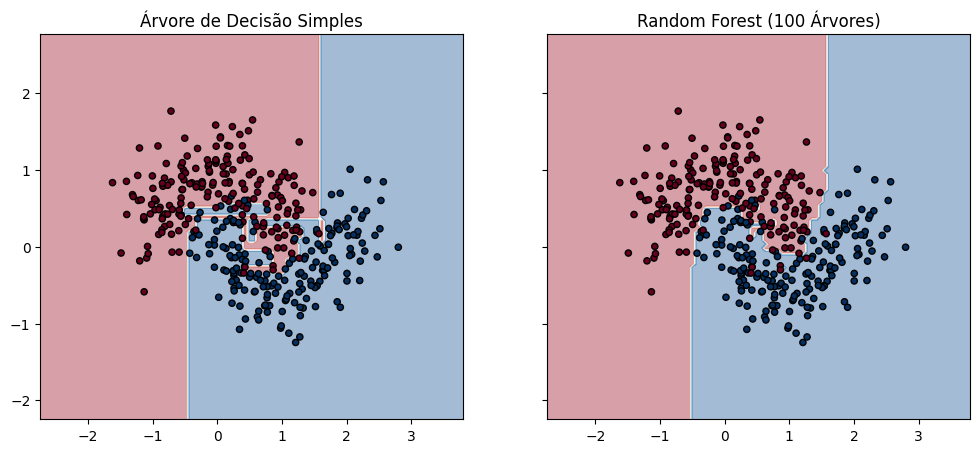

In [ ]:
# 3. Plotando as Fronteiras de Decisão
fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharey=True)

for ax, model, title in zip(axes, [tree_clf, rf_clf], ["Árvore de Decisão Simples", "Random Forest (100 Árvores)"]):
    DecisionBoundaryDisplay.from_estimator(
        model, X_moons, alpha=0.4, ax=ax, cmap="RdBu", response_method="predict"
    )
    ax.scatter(X_train_m[:, 0], X_train_m[:, 1], c=y_train_m, s=20, edgecolor="k", cmap="RdBu")
    ax.set_title(title)

plt.show()

In [ ]:
# Importância das features (Dataset Moons tem apenas Feature 0 e Feature 1)
print(f"Importância das Features (Moons): {rf_clf.feature_importances_}")

Importância das Features (Moons): [0.44658736 0.55341264]


### 1.1 A Anatomia da Floresta e Diversidade das Árvores

Uma Floresta Aleatória é composta por árvores treinadas em subconjuntos diferentes (Bootstrap) e atributos diferentes. Abaixo, isolamos duas árvores da nossa floresta para você ver como elas tomam decisões de forma completamente diferente!

In [ ]:
# Extraindo a primeira e a segunda árvore da nossa floresta
tree_1 = rf_clf.estimators_[0]
tree_2 = rf_clf.estimators_[1]

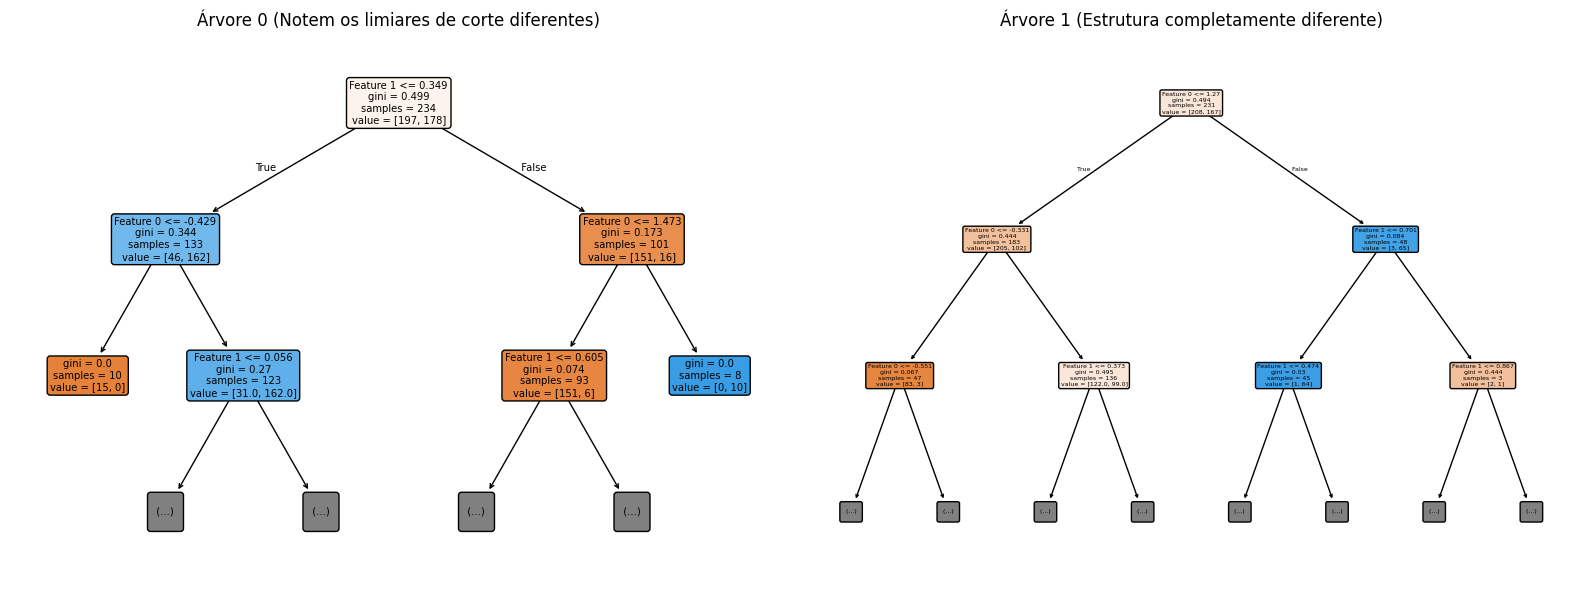

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(16, 6))

# Plotando as duas árvores (limitando a profundidade para ficar legível na tela)
plot_tree(tree_1, max_depth=2, filled=True, feature_names=["Feature 0", "Feature 1"], ax=axes[0], rounded=True)
axes[0].set_title("Árvore 0 (Notem os limiares de corte diferentes)")

plot_tree(tree_2, max_depth=2, filled=True, feature_names=["Feature 0", "Feature 1"], ax=axes[1], rounded=True)
axes[1].set_title("Árvore 1 (Estrutura completamente diferente)")

plt.tight_layout()
plt.show()

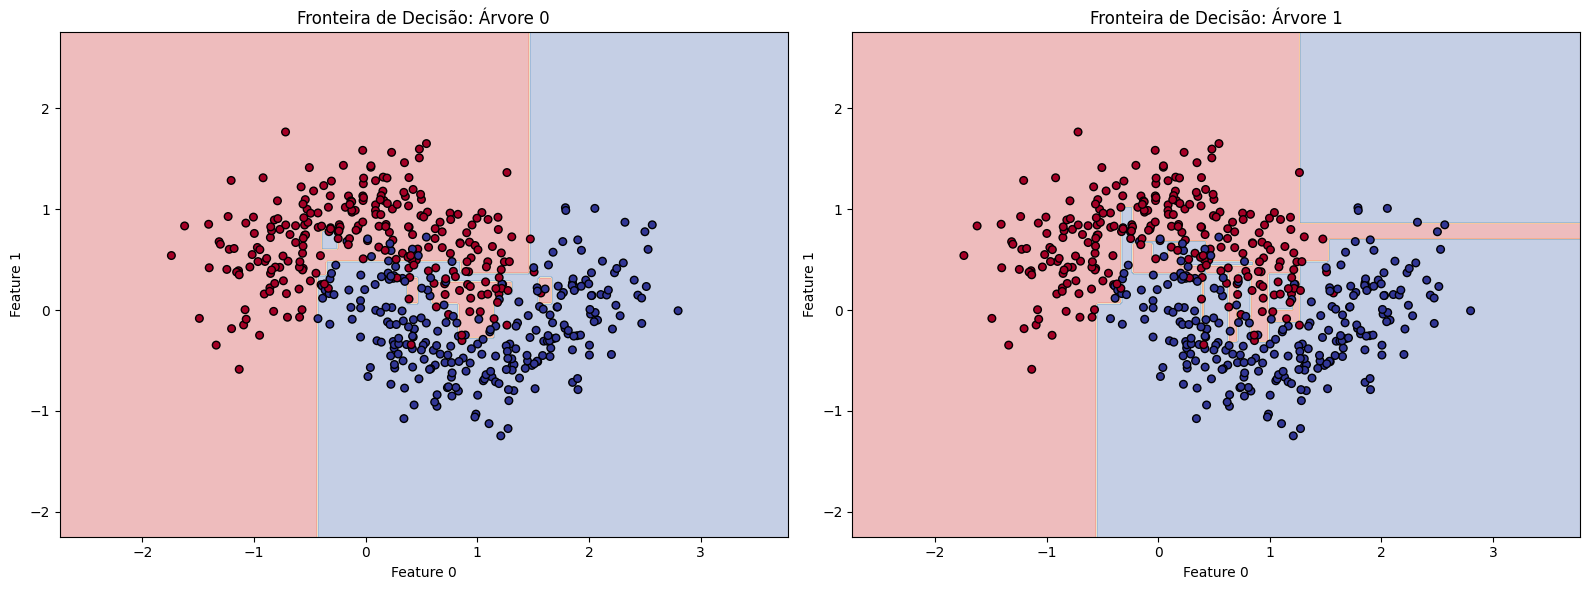

In [ ]:
def plot_decision_boundaries(clf, X, y, ax, title):
    # Definição dos limites do gráfico
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Criação da malha de pontos (meshgrid)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predição para cada ponto da malha
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot das regiões de decisão
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

    # Plot dos pontos originais para comparação
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap='RdYlBu')
    ax.set_title(title)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

# Configuração da figura para comparar as duas árvores
fig, axes = plt.subplots(ncols=2, figsize=(16, 6))

# Plotagem da fronteira para a Árvore 0
plot_decision_boundaries(tree_1, X_moons, y_moons, axes[0], "Fronteira de Decisão: Árvore 0")

# Plotagem da fronteira para a Árvore 1
plot_decision_boundaries(tree_2, X_moons, y_moons, axes[1], "Fronteira de Decisão: Árvore 1")

plt.tight_layout()
plt.show()

### 1.2 Por debaixo dos panos: A Votação Manual
Como a floresta decide? Ela pergunta a **todas** as suas árvores e faz uma votação. Vamos pegar um único ponto de teste e ver o que cada árvore diz:

In [ ]:
# Pegando a primeira amostra do conjunto de teste
amostra = X_test_m[0].reshape(1, -1)
print(f"Ponto a ser previsto: {amostra}\n")

Ponto a ser previsto: [[0.50169252 0.21717211]]



In [ ]:
# Pegando a predição de CADA árvore individual da floresta
predicoes_individuais = [int(tree.predict(amostra)[0]) for tree in rf_clf.estimators_]
predicoes_individuais[:10]

[1, 1, 1, 0, 0, 0, 0, 1, 0, 0]

In [ ]:
# Contando os votos
contagem_votos = collections.Counter(predicoes_individuais)

print(f"Votos para a Classe 0: {contagem_votos[0]}")
print(f"Votos para a Classe 1: {contagem_votos[1]}")
print("-" * 30)

Votos para a Classe 0: 48
Votos para a Classe 1: 52
------------------------------


In [ ]:
# O resultado final é a classe majoritária
vencedor = contagem_votos.most_common(1)[0][0]
resultado_oficial = rf_clf.predict(amostra)[0]

print(f"Veredito Agregado (Maioria): Classe {vencedor}")
print(f"Predição Oficial do Modelo: Classe {resultado_oficial}")

Veredito Agregado (Maioria): Classe 1
Predição Oficial do Modelo: Classe 1


## 2. Lidando com Alta Dimensionalidade: Câncer de Mama

Dataset **Breast Cancer** possui 30 atributos (features).
> **Nota de Pré-processamento:** Diferente de algoritmos como KNN e SVM, a Random Forest não exige a padronização (escalonamento) dos dados, pois atua dividindo o espaço em nós e limiares, independentemente da escala.

Aqui vamos demonstrar três conceitos avançados:
1. **OOB Score (Out-of-Bag):** A Random Forest valida a si mesma durante o treino usando as amostras que não foram sorteadas pelo *Bootstrap*.
2. **Feature Importance:** Selecionando as variáveis que mais importam para o diagnóstico.
3. **Extra-Trees:** Uma variação ainda mais aleatória e rápida.

In [ ]:
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, random_state=42)

In [ ]:
# 1. Treinando RF com OOB Score ativado
rf_cancer = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1)

start_time = time.time()
rf_cancer.fit(X_train_c, y_train_c)
tempo_rf = time.time() - start_time

print(f"Tempo de Treino (Random Forest): {tempo_rf:.4f} segundos")
print(f"Acurácia OOB (Validação Interna): {rf_cancer.oob_score_:.4f}")
print(f"Acurácia de Teste Real: {accuracy_score(y_test_c, rf_cancer.predict(X_test_c)):.4f}\n")

Tempo de Treino (Random Forest): 0.8114 segundos
Acurácia OOB (Validação Interna): 0.9601
Acurácia de Teste Real: 0.9650



In [ ]:
# 2. Comparando com Extra-Trees
et_cancer = ExtraTreesClassifier(n_estimators=200, bootstrap=True, oob_score=True, random_state=42, n_jobs=-1)

start_time = time.time()
et_cancer.fit(X_train_c, y_train_c)
tempo_et = time.time() - start_time

print(f"Tempo de Treino (Extra-Trees): {tempo_et:.4f} segundos (Geralmente mais rápido!)")
print(f"Acurácia OOB (Validação Interna): {et_cancer.oob_score_:.4f}")
print(f"Acurácia Extra-Trees (Teste): {accuracy_score(y_test_c, et_cancer.predict(X_test_c)):.4f}")

Tempo de Treino (Extra-Trees): 0.7883 segundos (Geralmente mais rápido!)
Acurácia OOB (Validação Interna): 0.9648
Acurácia Extra-Trees (Teste): 0.9790


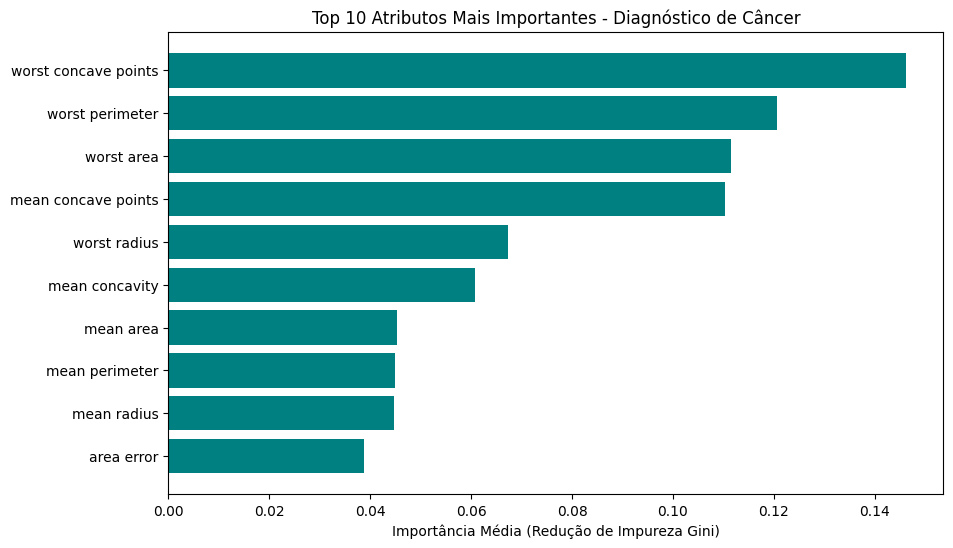

In [ ]:
# 3. Visualizando a Importância dos Atributos
importances = rf_cancer.feature_importances_
df_imp = pd.DataFrame({"Feature": cancer.feature_names, "Importancia": importances})
df_imp = df_imp.sort_values(by="Importancia", ascending=False).head(10) # Pegando top 10

plt.figure(figsize=(10, 6))
plt.barh(df_imp["Feature"][::-1], df_imp["Importancia"][::-1], color='teal')
plt.xlabel("Importância Média (Redução de Impureza Gini)")
plt.title("Top 10 Atributos Mais Importantes - Diagnóstico de Câncer")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definindo a grade de parâmetros para testar
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Inicializando e rodando o GridSearchCV
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1, scoring='f1')
grid_search.fit(X_train_c, y_train_c)

print(f"Melhores hiperparâmetros encontrados: {grid_search.best_params_}")

Melhores hiperparâmetros encontrados: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}


In [ ]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.370680,0.060880,0.025177,0.012166,None,sqrt,50,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.956989,0.960452,0.972067,0.963169,0.006448,1
1,0.689454,0.117818,0.033022,0.009973,None,sqrt,100,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.956989,0.960000,0.966667,0.961219,0.004044,9
2,1.083846,0.137112,0.041854,0.015511,None,sqrt,200,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.956989,0.960452,0.967033,0.961491,0.004166,4
3,0.244618,0.031939,0.011509,0.000409,None,log2,50,"{'max_depth': None, 'max_features': 'log2', 'n...",0.956989,0.954545,0.949721,0.953752,0.003020,17
4,0.342199,0.013565,0.021024,0.002132,None,log2,100,"{'max_depth': None, 'max_features': 'log2', 'n...",0.956989,0.966292,0.960894,0.961392,0.003814,6
5,0.716523,0.013931,0.030931,0.002236,None,log2,200,"{'max_depth': None, 'max_features': 'log2', 'n...",0.951351,0.960452,0.955556,0.955786,0.003719,14
6,0.186908,0.013313,0.013697,0.001185,5,sqrt,50,"{'max_depth': 5, 'max_features': 'sqrt', 'n_es...",0.962162,0.965909,0.960894,0.962988,0.002129,3
7,0.357206,0.011958,0.018391,0.000952,5,sqrt,100,"{'max_depth': 5, 'max_features': 'sqrt', 'n_es...",0.951872,0.966292,0.955556,0.957906,0.006117,13
8,0.693254,0.027142,0.028166,0.000541,5,sqrt,200,"{'max_depth': 5, 'max_features': 'sqrt', 'n_es...",0.956989,0.960452,0.961326,0.959589,0.001873,11
9,0.157458,0.002001,0.011127,0.000653,5,log2,50,"{'max_depth': 5, 'max_features': 'log2', 'n_es...",0.956522,0.966292,0.960894,0.961236,0.003996,8


In [ ]:
# O GridSearchCV já guarda o melhor modelo treinado no atributo 'best_estimator_'
melhor_modelo_rf = grid_search.best_estimator_

# Predição e Avaliação com o melhor modelo
y_pred_otimizado = melhor_modelo_rf.predict(X_test_c)
acuracia_otimizada = accuracy_score(y_test_c, y_pred_otimizado)

print(f"Acurácia no Teste com o modelo otimizado: {acuracia_otimizada:.4f}")

Acurácia no Teste com o modelo otimizado: 0.9720


## 3. MNIST: Enxergando através de Pixels

O dataset MNIST contém imagens de dígitos escritos à mão (28x28 pixels = 784 features).

Vamos usar a "Importância de Features" para criar um **Mapa de Calor**. Isso nos revelará quais partes da imagem a Random Forest considera cruciais para identificar o número.

In [ ]:
# Carregando dados
mnist = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False, parser='auto')
X_mnist, y_mnist = mnist

Rótulo:  5


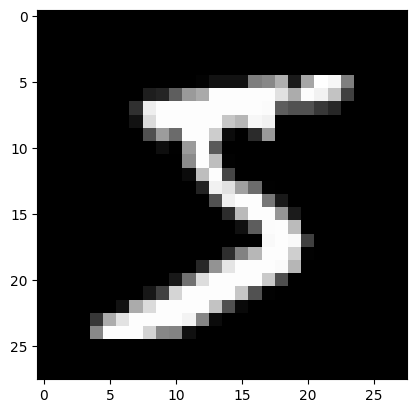

In [ ]:
print("Rótulo: ", y_mnist[0])
plt.gray()
plt.imshow(X_mnist[0].reshape((28,28)))
plt.show()

In [ ]:
X_mnist.shape

(70000, 784)

In [ ]:
# Embaralhando e pegando uma amostra menor (15k para treino, 3k para teste)
indices = np.random.permutation(len(X_mnist))
X_train_mn = X_mnist[indices[:15000]]
y_train_mn = y_mnist[indices[:15000]]
X_test_mn = X_mnist[indices[15000:18000]]
y_test_mn = y_mnist[indices[15000:18000]]

In [ ]:
# Treinando a Floresta
rnd_clf_mnist = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rnd_clf_mnist.fit(X_train_mn, y_train_mn)

# Avaliando
print(f"Acurácia MNIST (Amostra): {accuracy_score(y_test_mn, rnd_clf_mnist.predict(X_test_mn)):.4f}")

Acurácia MNIST (Amostra): 0.9527


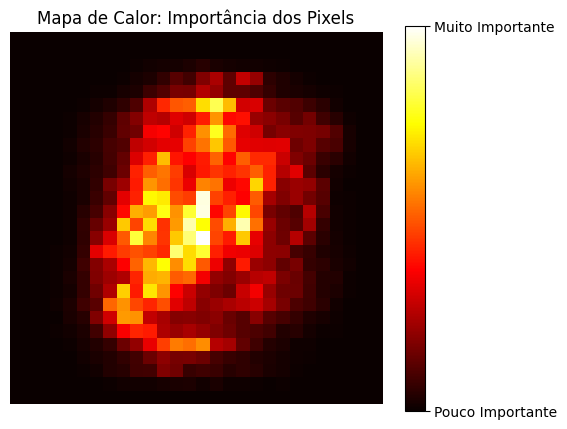

In [ ]:
# Plotando a Importância de cada pixel como uma Imagem
def plot_digit_importance(importances):
    image = importances.reshape(28, 28)
    plt.imshow(image, cmap=matplotlib.cm.hot, interpolation="nearest")
    plt.axis("off")
    cbar = plt.colorbar(ticks=[importances.min(), importances.max()])
    cbar.ax.set_yticklabels(['Pouco Importante', 'Muito Importante'])
    plt.title("Mapa de Calor: Importância dos Pixels")

plt.figure(figsize=(6, 5))
plot_digit_importance(rnd_clf_mnist.feature_importances_)
plt.show()

<Figure size 1000x800 with 0 Axes>

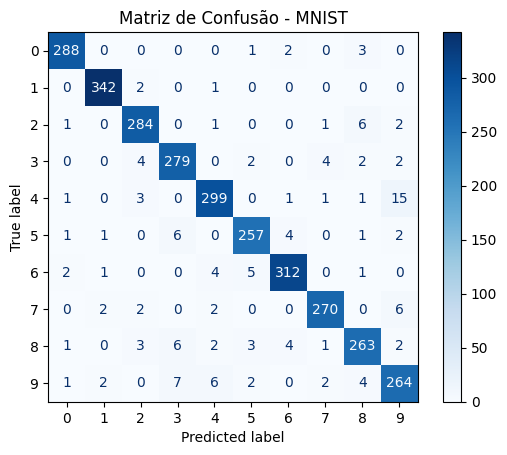

In [ ]:
# Onde o modelo erra? Matriz de Confusão
plt.figure(figsize=(10, 8))
y_pred_mn = rnd_clf_mnist.predict(X_test_mn)

ConfusionMatrixDisplay.from_predictions(y_test_mn, y_pred_mn, cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - MNIST")
plt.show()

## 4. Florestas para Regressão (Valores Contínuos)

Até agora, usamos o modelo para **Classificação** (prever categorias como Câncer Benigno/Maligno ou Dígitos de 0 a 9). Mas a Floresta Aleatória também é excelente para **Regressão** (prever números contínuos, como preços de casas ou temperatura).



Na regressão, em vez de "votar" na classe mais frequente, a floresta calcula a **média aritmética** das previsões de todas as árvores. Visualmente, isso cria uma fronteira de decisão em formato de "degraus", pois as árvores de decisão particionam os dados em regiões retangulares.

In [ ]:
# Gerando dados sintéticos: uma onda senoidal (função não-linear) com um pouco de ruído
rng = np.random.RandomState(42)
X_reg = np.sort(5 * rng.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel()
y_reg[::5] += 3 * (0.5 - rng.rand(16)) # Adicionando ruído (outliers) a alguns pontos

In [ ]:
# Treinando a Floresta Aleatória para Regressão
# Limitamos o max_depth para evitar que a árvore decore completamente o ruído (overfitting)
regr_rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
regr_rf.fit(X_reg, y_reg)

RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

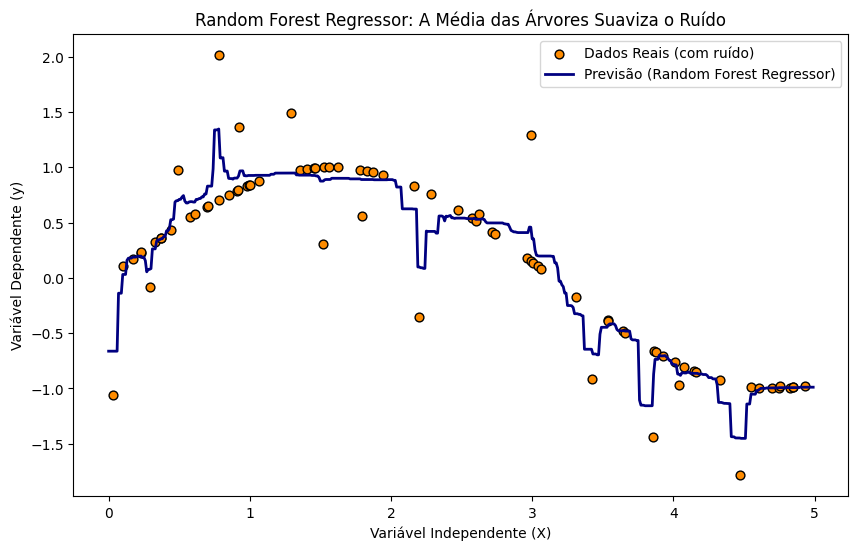

In [ ]:
# Criando dados de teste (uma linha contínua) para visualizar a predição
X_test_reg = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred_reg = regr_rf.predict(X_test_reg)

# Plotando os dados e a fronteira de regressão em formato de "degraus"
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, c="darkorange", edgecolor="k", s=40, label="Dados Reais (com ruído)")
plt.plot(X_test_reg, y_pred_reg, color="navy", lw=2, label="Previsão (Random Forest Regressor)")

plt.xlabel("Variável Independente (X)")
plt.ylabel("Variável Dependente (y)")
plt.title("Random Forest Regressor: A Média das Árvores Suaviza o Ruído")
plt.legend()
plt.show()

## 5. Lidando com Dados Desequilibrados

Na prática (como em deteção de fraudes ou diagnósticos médicos raros), é comum termos datasets onde uma classe representa 99% dos dados e a outra apenas 1%.
Modelos tradicionais tendem a ignorar a classe minoritária. Felizmente, a *Random Forest* possui um parâmetro chamado `class_weight='balanced'`, que ajusta automaticamente a importância da classe minoritária durante o treinamento, penalizando fortemente os erros cometidos nela.

Vamos simular um cenário de fraude bancária onde apenas 5% das transações são fraudes (Classe 1).

In [ ]:
# Criando um dataset com mais dados (5000) para garantir que a minoria tenha representatividade
# 95% Normal (Classe 0), 5% Fraude (Classe 1)
X_imb, y_imb = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    weights=[0.95, 0.05],
    random_state=42
)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)

In [ ]:
print("--- Modelo Padrão (Ignora o Desequilíbrio) ---")
rf_normal = RandomForestClassifier(random_state=42)
rf_normal.fit(X_train_i, y_train_i)

# O recall da classe 1 mostra o percentual de fraudes reais que o modelo conseguiu achar
print(classification_report(y_test_i, rf_normal.predict(X_test_i)))

--- Modelo Padrão (Ignora o Desequilíbrio) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1420
           1       0.96      0.33      0.49        80

    accuracy                           0.96      1500
   macro avg       0.96      0.66      0.73      1500
weighted avg       0.96      0.96      0.95      1500



In [ ]:
print("\n--- Modelo Balanceado (Sensível à Fraude) ---")
# Usamos 'balanced_subsample' porque é o ideal para algoritmos baseados em Bagging/Bootstrap
# Para evitar que o modelo decore o ruído da maioria, também limitamos a profundidade (max_depth)
rf_balanceado = RandomForestClassifier(class_weight='balanced_subsample', max_depth=10, random_state=42)
rf_balanceado.fit(X_train_i, y_train_i)

# O "Recall" da classe 1 (Fraude) deve aumentar significativamente!
# O modelo sacrifica a "Precision" da maioria para não deixar fraudes passarem.
print(classification_report(y_test_i, rf_balanceado.predict(X_test_i)))


--- Modelo Balanceado (Sensível à Fraude) ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1420
           1       0.87      0.41      0.56        80

    accuracy                           0.97      1500
   macro avg       0.92      0.70      0.77      1500
weighted avg       0.96      0.97      0.96      1500

